# Evaluation of All Four Models

This notebook answers the question the previous notebook could not: whether the hybrid model actually recommends better than the three models it combines. No new models are built here. The four existing models are placed on the same test data and measured with the same metrics.

The earlier notebooks reported RMSE and MAE, which measure how close a predicted rating is to the true one. Those metrics say nothing about whether the right items reach the top of a list, which is what a user actually sees. This notebook therefore adds ranking metrics: Precision@K, Recall@K and NDCG@K.

Measuring a ranking requires knowing which items a user genuinely wanted. I use a held-out protocol: for each test user, a portion of the items they rated highly is hidden, each model ranks the catalogue without seeing them, and the metrics record how many of the hidden items each model recovered in its top K. The evaluation also includes repeated random splits to confirm the results do not depend on one particular split, a paired significance test, and the qualitative persona protocol set out in my Design chapter.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Loading the saved models
import pickle

# Semantic model
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Statistical testing
from scipy import stats

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


---
## Loading the catalogues, models and ratings

Everything evaluated here was built in the earlier notebooks and is loaded rather than rebuilt. The ratings tables are also loaded, since the held-out protocol needs to know which items each user actually rated highly.

In [2]:
# Catalogues, with popularity already normalised
courses = pd.read_csv('courses_final.csv')
books = pd.read_csv('books_final.csv')

# Ratings
reviews = pd.read_csv('coursera_reviews_filtered.csv')
ratings = pd.read_csv('ratings_filtered.csv')

# Semantic embeddings
course_embeddings = np.load('course_embeddings.npy')
book_embeddings = np.load('book_embeddings.npy')

# Trained collaborative filtering models
with open('cf_model_courses.pkl', 'rb') as f:
    cf_courses = pickle.load(f)
with open('cf_model_books.pkl', 'rb') as f:
    cf_books = pickle.load(f)

# Semantic model, needed to encode queries typed by the user
sbert = SentenceTransformer('all-MiniLM-L6-v2')

# The weights chosen in the hybrid notebook
with open('hybrid_config.pkl', 'rb') as f:
    config = pickle.load(f)

print(f"Courses: {len(courses)}   reviews: {len(reviews):,}")
print(f"Books:   {len(books)}   ratings: {len(ratings):,}")
print(f"Embeddings: {course_embeddings.shape} and {book_embeddings.shape}")
print(f"\nHybrid weights in use: {config}")

Courses: 336   reviews: 1,019,660
Books:   593   ratings: 217,744
Embeddings: (336, 384) and (593, 384)

Hybrid weights in use: {'w_collaborative': 0.35, 'w_semantic': 0.45, 'w_popularity': 0.2, 'book_threshold': 0.3, 'sbert_model': 'all-MiniLM-L6-v2'}


---
## Rebuilding the item factor matrices

The collaborative signal used in the evaluation is the same one the hybrid uses: the latent item factors learned by the SVD model, aligned with the catalogue row order so that all four models index items identically.

In [3]:
def item_factor_matrix(cf_model, id_list):
    """Extract the SVD latent item factors, aligned with the catalogue row order."""
    n_factors = cf_model.qi.shape[1]
    factors = np.zeros((len(id_list), n_factors))
    for i, raw_id in enumerate(id_list):
        try:
            inner = cf_model.trainset.to_inner_iid(raw_id)
            factors[i] = cf_model.qi[inner]
        except ValueError:
            pass
    return factors

course_factors = item_factor_matrix(cf_courses, courses['course_id'].tolist())
book_factors = item_factor_matrix(cf_books, books['book_id'].tolist())

print(f"Course factors: {course_factors.shape}")
print(f"Book factors:   {book_factors.shape}")

Course factors: (336, 50)
Book factors:   (593, 50)


---
## Selecting the evaluation users

A ranking metric needs a user who liked enough courses for some to be hidden while others remain as a profile. I select users who rated at least six different courses four or five, hide two of them, and use the rest as the profile. This biases the sample towards active users, which is noted in the final discussion.

In [4]:
MIN_LIKED = 6      # a user must have rated at least this many different courses 4 or 5
N_HELD_OUT = 2     # how many of their liked courses are hidden from the models

# Keep only high ratings, drop placeholder accounts, and remove duplicate
# reviewer-course pairs so that each course is counted once per user
liked = reviews[reviews['rating'] >= 4].copy()
liked = liked[~liked['reviewers'].str.contains('Deleted', case=False, na=False)]

before = len(liked)
liked = liked.drop_duplicates(subset=['reviewers', 'course_id'])
print(f"Duplicate reviewer-course pairs removed: {before - len(liked):,}")

# Count how many distinct courses each user liked
liked_counts = liked.groupby('reviewers').size()
eligible = liked_counts[liked_counts >= MIN_LIKED].index

print(f"\nUsers who liked at least {MIN_LIKED} different courses: {len(eligible):,}")
print(f"That is {len(eligible) / reviews['reviewers'].nunique() * 100:.1f}% of all reviewers")
print(f"\nDistinct liked courses per eligible user:")
print(f"  Median: {liked_counts[eligible].median():.0f}")
print(f"  Mean:   {liked_counts[eligible].mean():.1f}")
print(f"  Max:    {liked_counts[eligible].max():.0f}")

Duplicate reviewer-course pairs removed: 628,193

Users who liked at least 6 different courses: 6,228
That is 3.1% of all reviewers

Distinct liked courses per eligible user:
  Median: 8
  Mean:   10.2
  Max:    87


> The reviews table contains 628,193 repeated reviewer-course pairs, so counting rows rather than distinct courses overstated how many users had a history long enough to evaluate. Counting distinct courses reduces the eligible pool from 47,147 to 6,228, or 3.1% of all reviewers. The remaining 97% rated fewer than six courses, which is the sparsity problem expressed in human terms and the reason a content-based model is necessary alongside collaborative filtering.

---
## Building the held-out test set

The hidden courses are the correct answers: a model performs well if it ranks them near the top without having seen them. I sample 500 users rather than all 6,228, since each user requires every model to score the whole catalogue.

In [5]:
SAMPLE_SIZE = 500
rng = np.random.RandomState(42)

sample_users = rng.choice(eligible, size=min(SAMPLE_SIZE, len(eligible)), replace=False)

# Map course_id to its row position, so all models index items the same way
course_pos = {cid: i for i, cid in enumerate(courses['course_id'])}

# Group once, which is far faster than filtering the table per user
liked_by_user = liked.groupby('reviewers')['course_id'].apply(list)

# Build one test case per user: a profile the models see, and hidden answers
test_cases = []
for user in sample_users:
    user_liked = [c for c in liked_by_user[user] if c in course_pos]
    if len(user_liked) < MIN_LIKED:
        continue
    shuffled = rng.permutation(user_liked)
    test_cases.append({
        'user': user,
        'profile': [course_pos[c] for c in shuffled[N_HELD_OUT:]],
        'held_out': [course_pos[c] for c in shuffled[:N_HELD_OUT]],
        'rated_all': [course_pos[c] for c in user_liked]
    })

print(f"Test cases built: {len(test_cases)} out of {len(sample_users)} users sampled")

example = test_cases[0]
print(f"\nExample test case:")
print(f"  Profile:    {len(example['profile'])} courses the models can see")
print(f"  Held out:   {len(example['held_out'])} courses hidden as the answers")
print(f"\n  A profile course: {courses.iloc[example['profile'][0]]['name'][:50]}")
print(f"  A hidden answer:  {courses.iloc[example['held_out'][0]]['name'][:50]}")

Test cases built: 500 out of 500 users sampled

Example test case:
  Profile:    8 courses the models can see
  Held out:   2 courses hidden as the answers

  A profile course: Introduction to TensorFlow for Artificial Intellig
  A hidden answer:  Data Science Methodology


---
## The four models as scoring functions

Each model must produce one score per course from the same input so the comparison is fair. The popularity baseline ignores the profile, collaborative filtering predicts this user's rating for every course, the semantic model compares the profile's average embedding to every course, and the hybrid combines all three using the weights chosen in the previous notebook.

In [6]:
W_CF = config['w_collaborative']
W_SEM = config['w_semantic']
W_POP = config['w_popularity']

popularity_vector = courses['popularity_norm'].values


def score_popularity(case):
    """Same ranking for every user."""
    return popularity_vector


def score_cf(case):
    """Predicted rating from the trained SVD model, rescaled to 0 to 1."""
    preds = np.zeros(len(courses))
    for i, cid in enumerate(courses['course_id']):
        preds[i] = cf_courses.predict(case['user'], cid).est
    return (preds - 1) / 4


def score_semantic(case):
    """Cosine similarity to the average embedding of the profile courses."""
    profile = course_embeddings[case['profile']].mean(axis=0).reshape(1, -1)
    return np.clip(cosine_similarity(profile, course_embeddings).flatten(), 0, 1)


def score_hybrid(case):
    """Weighted combination of the three signals."""
    collab = np.clip(cosine_similarity(
        course_factors[case['profile']].mean(axis=0).reshape(1, -1),
        course_factors).flatten(), 0, 1)
    return (W_CF * collab
            + W_SEM * score_semantic(case)
            + W_POP * popularity_vector)


models = {
    'Popularity': score_popularity,
    'Collaborative filtering': score_cf,
    'Content-based (semantic)': score_semantic,
    'Hybrid': score_hybrid
}

for name, fn in models.items():
    s = fn(test_cases[0])
    print(f"{name:<26} scores: {s.shape}   range {s.min():.3f} to {s.max():.3f}")

Popularity                 scores: (336,)   range 0.000 to 1.000
Collaborative filtering    scores: (336,)   range 0.563 to 1.000
Content-based (semantic)   scores: (336,)   range 0.000 to 0.694
Hybrid                     scores: (336,)   range 0.010 to 0.660


> The score ranges already suggest a difference in behaviour. The semantic and popularity signals both span most of the 0 to 1 range, whereas collaborative filtering compresses into 0.563 to 1.000. Because 76.8% of ratings are five stars, the SVD model predicts a high rating for almost every course, which leaves it little room to separate one course from another.

---
## The three ranking metrics

Precision@10 asks what proportion of the ten recommended courses were among the hidden answers. Recall@10 asks what proportion of the hidden answers were found. NDCG@10 asks the same as recall but rewards placing a correct answer near the top of the list.

Because only two courses are hidden per user, the highest Precision@10 any model can reach is 0.2.

In [7]:
def evaluate_case(scores, case, k=10):
    """Score one user's ranked list with Precision@K, Recall@K and NDCG@K."""
    profile = set(case['profile'])
    answers = set(case['held_out'])

    # Rank every course the model was not shown, best first
    ranked = [i for i in np.argsort(scores)[::-1] if i not in profile][:k]
    hits = [1 if i in answers else 0 for i in ranked]

    precision = sum(hits) / k
    recall = sum(hits) / len(answers)

    # NDCG rewards a correct answer appearing higher in the list
    dcg = sum(h / np.log2(pos + 2) for pos, h in enumerate(hits))
    ideal = sum(1 / np.log2(pos + 2) for pos in range(min(len(answers), k)))
    ndcg = dcg / ideal if ideal > 0 else 0.0

    return precision, recall, ndcg


# Check the function on the first five test cases
print("Hybrid model on the first five test users:\n")
print(f"{'User':<6}{'Precision@10':>14}{'Recall@10':>12}{'NDCG@10':>10}")
for i in range(5):
    p, r, n = evaluate_case(score_hybrid(test_cases[i]), test_cases[i])
    print(f"{i+1:<6}{p:>14.3f}{r:>12.3f}{n:>10.3f}")

Hybrid model on the first five test users:

User    Precision@10   Recall@10   NDCG@10
1              0.000       0.000     0.000
2              0.000       0.000     0.000
3              0.100       0.500     0.387
4              0.000       0.000     0.000
5              0.000       0.000     0.000


> Most individual users score zero, which is expected rather than a fault. With 336 courses, two correct answers and ten slots, random guessing would succeed roughly six percent of the time, so a single user carries almost no information. The comparison between models emerges only in the average across all 500.

In [8]:
results = []

for name, score_fn in models.items():
    print(f"Evaluating {name}...")
    precisions, recalls, ndcgs = [], [], []
    for case in test_cases:
        p, r, n = evaluate_case(score_fn(case), case)
        precisions.append(p)
        recalls.append(r)
        ndcgs.append(n)
    results.append({
        'Model': name,
        'Precision@10': np.mean(precisions),
        'Recall@10': np.mean(recalls),
        'NDCG@10': np.mean(ndcgs)
    })

results_df = pd.DataFrame(results).round(4)
print("\nResults across 500 test users:\n")
print(results_df.to_string(index=False))

Evaluating Popularity...
Evaluating Collaborative filtering...
Evaluating Content-based (semantic)...
Evaluating Hybrid...

Results across 500 test users:

                   Model  Precision@10  Recall@10  NDCG@10
              Popularity        0.0530      0.265   0.1745
 Collaborative filtering        0.0086      0.043   0.0246
Content-based (semantic)        0.0296      0.148   0.0966
                  Hybrid        0.0472      0.236   0.1742


> Three findings emerge, none of them the result I expected.
>
> The popularity baseline leads on every metric. This reflects how the test is built rather than model quality: the hidden courses are ones the user rated, and heavily rated courses are popular by definition, which favours a popularity ranking.
>
> Collaborative filtering achieved the best RMSE of any model at 0.481 but the worst ranking at 0.0086, barely above random selection. The two metric families order the models in opposite directions, which is direct evidence for the argument in my Design chapter that rating accuracy and ranking quality measure different things.
>
> The hybrid is the strongest of the three personalised models and the only one that comes close to the baseline, though the size of that gap varies between splits, as the stability check below shows.

---
## Comparing the models visually

The three metrics are plotted together so the gap between the models can be read at a glance.

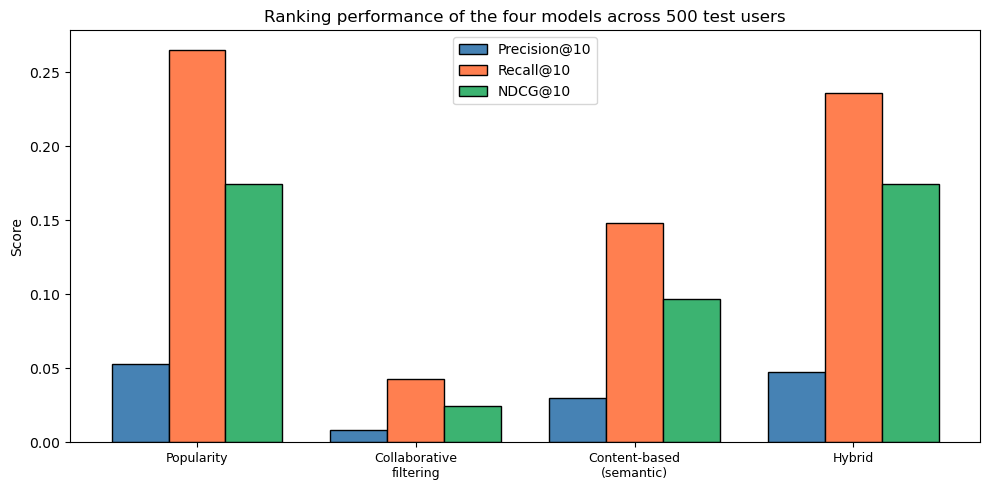

In [9]:
metrics = ['Precision@10', 'Recall@10', 'NDCG@10']
x = np.arange(len(results_df))
width = 0.26
colours = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + (i - 1) * width, results_df[metric], width,
           label=metric, color=colours[i], edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in results_df['Model']], fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Ranking performance of the four models across 500 test users')
ax.legend()
plt.tight_layout()
plt.show()

---
## Testing whether the difference is significant

The hybrid and the popularity baseline differ by 0.0004 on NDCG@10. A paired t-test on the per-user scores establishes whether that gap is meaningful or simply noise, since both models were measured on exactly the same users.

In [10]:
# Collect per-user NDCG scores for the two closest models
ndcg_pop, ndcg_hyb = [], []
for case in test_cases:
    ndcg_pop.append(evaluate_case(score_popularity(case), case)[2])
    ndcg_hyb.append(evaluate_case(score_hybrid(case), case)[2])

ndcg_pop = np.array(ndcg_pop)
ndcg_hyb = np.array(ndcg_hyb)

t_stat, p_value = stats.ttest_rel(ndcg_hyb, ndcg_pop)

print(f"Mean NDCG@10 — popularity: {ndcg_pop.mean():.4f}")
print(f"Mean NDCG@10 — hybrid:     {ndcg_hyb.mean():.4f}")
print(f"Difference:                {ndcg_hyb.mean() - ndcg_pop.mean():+.4f}")
print(f"\nPaired t-test:  t = {t_stat:.3f},  p = {p_value:.3f}")
print(f"Significant at the 5% level: {p_value < 0.05}")

Mean NDCG@10 — popularity: 0.1745
Mean NDCG@10 — hybrid:     0.1742
Difference:                -0.0004

Paired t-test:  t = -0.024,  p = 0.981
Significant at the 5% level: False


> On this split the difference between the hybrid and the popularity baseline is 0.0004 with a p-value of 0.981, so the two are statistically indistinguishable. The test cannot show that either model ranks better than the other here.

---
## Checking the result is stable

The evaluation so far rests on one random split. Repeating it with three different seeds shows whether the ranking of the models depends on which users were sampled and which courses were hidden.

In [11]:
REPEAT_SAMPLE = 300

stability = {name: [] for name in models}

for seed in [7, 21, 99]:
    r = np.random.RandomState(seed)
    users = r.choice(eligible, size=REPEAT_SAMPLE, replace=False)

    cases = []
    for user in users:
        user_liked = [c for c in liked_by_user[user] if c in course_pos]
        if len(user_liked) < MIN_LIKED:
            continue
        shuffled = r.permutation(user_liked)
        cases.append({
            'user': user,
            'profile': [course_pos[c] for c in shuffled[N_HELD_OUT:]],
            'held_out': [course_pos[c] for c in shuffled[:N_HELD_OUT]]
        })

    for name, fn in models.items():
        scores = [evaluate_case(fn(c), c)[2] for c in cases]
        stability[name].append(np.mean(scores))
    print(f"Seed {seed} complete ({len(cases)} users)")

print("\nNDCG@10 across three independent splits:\n")
print(f"{'Model':<26}{'Split 1':>10}{'Split 2':>10}{'Split 3':>10}{'Mean':>10}{'Std':>8}")
for name, vals in stability.items():
    print(f"{name:<26}{vals[0]:>10.4f}{vals[1]:>10.4f}{vals[2]:>10.4f}"
          f"{np.mean(vals):>10.4f}{np.std(vals):>8.4f}")

Seed 7 complete (300 users)
Seed 21 complete (300 users)
Seed 99 complete (300 users)

NDCG@10 across three independent splits:

Model                        Split 1   Split 2   Split 3      Mean     Std
Popularity                    0.2132    0.1920    0.1907    0.1986  0.0103
Collaborative filtering       0.0246    0.0246    0.0327    0.0273  0.0038
Content-based (semantic)      0.0985    0.0982    0.0938    0.0968  0.0021
Hybrid                        0.1751    0.1695    0.1648    0.1698  0.0042


> The ordering of the four models is identical across all three splits, and the standard deviations range from 0.002 to 0.010, so the result does not depend on which users were sampled. The wider view also qualifies the t-test above: the two models were indistinguishable on the first split, but across these three the popularity baseline leads the hybrid by roughly 0.03 on NDCG@10. The baseline is therefore the stronger performer on offline ranking, with a margin that varies by split.

---
## Repeating the evaluation on the book catalogue

The same protocol is applied to the books so the two catalogues can be compared. Users who rated at least six different books four or five are sampled, two are hidden, and the four models are scored on the same held-out answers.

In [12]:
# Build the book test set using the same protocol
liked_b = ratings[ratings['rating'] >= 4].drop_duplicates(subset=['user_id', 'book_id'])
counts_b = liked_b.groupby('user_id').size()
eligible_b = counts_b[counts_b >= MIN_LIKED].index

book_pos = {bid: i for i, bid in enumerate(books['book_id'])}
liked_by_user_b = liked_b.groupby('user_id')['book_id'].apply(list)

rb = np.random.RandomState(42)
sample_b = rb.choice(eligible_b, size=min(500, len(eligible_b)), replace=False)

test_cases_b = []
for user in sample_b:
    ul = [b for b in liked_by_user_b[user] if b in book_pos]
    if len(ul) < MIN_LIKED:
        continue
    sh = rb.permutation(ul)
    test_cases_b.append({
        'user': user,
        'profile': [book_pos[b] for b in sh[N_HELD_OUT:]],
        'held_out': [book_pos[b] for b in sh[:N_HELD_OUT]]
    })

print(f"Eligible book users: {len(eligible_b):,}")
print(f"Book test cases built: {len(test_cases_b)}")

Eligible book users: 8,650
Book test cases built: 500


In [13]:
popularity_vector_b = books['popularity_norm'].values

def score_popularity_b(case):
    """Same ranking for every user."""
    return popularity_vector_b

def score_cf_b(case):
    """Predicted rating from the trained SVD model, rescaled to 0 to 1."""
    preds = np.zeros(len(books))
    for i, bid in enumerate(books['book_id']):
        preds[i] = cf_books.predict(case['user'], bid).est
    return (preds - 1) / 4

def score_semantic_b(case):
    """Cosine similarity to the average embedding of the profile books."""
    profile = book_embeddings[case['profile']].mean(axis=0).reshape(1, -1)
    return np.clip(cosine_similarity(profile, book_embeddings).flatten(), 0, 1)

def score_hybrid_b(case):
    """Weighted combination of the three signals."""
    collab = np.clip(cosine_similarity(
        book_factors[case['profile']].mean(axis=0).reshape(1, -1),
        book_factors).flatten(), 0, 1)
    return (W_CF * collab + W_SEM * score_semantic_b(case) + W_POP * popularity_vector_b)

models_b = {
    'Popularity': score_popularity_b,
    'Collaborative filtering': score_cf_b,
    'Content-based (semantic)': score_semantic_b,
    'Hybrid': score_hybrid_b
}

results_b = []
for name, fn in models_b.items():
    print(f"Evaluating {name}...")
    scores = [evaluate_case(fn(c), c) for c in test_cases_b]
    results_b.append({
        'Model': name,
        'Precision@10': np.mean([s[0] for s in scores]),
        'Recall@10': np.mean([s[1] for s in scores]),
        'NDCG@10': np.mean([s[2] for s in scores])
    })

results_b_df = pd.DataFrame(results_b).round(4)
print(f"\nBook results across {len(test_cases_b)} test users:\n")
print(results_b_df.to_string(index=False))

Evaluating Popularity...
Evaluating Collaborative filtering...
Evaluating Content-based (semantic)...
Evaluating Hybrid...

Book results across 500 test users:

                   Model  Precision@10  Recall@10  NDCG@10
              Popularity        0.0300      0.150   0.0977
 Collaborative filtering        0.0066      0.033   0.0173
Content-based (semantic)        0.0158      0.079   0.0491
                  Hybrid        0.0408      0.204   0.1463


> The book catalogue reverses the course result. The hybrid leads on all three metrics, improving on the popularity baseline by 36% on Precision@10 and Recall@10 and by 50% on NDCG@10.

> The difference between the two catalogues comes from their data rather than their models. On the course side, 76.8% of ratings are five stars and only 3.1% of reviewers rated six or more courses, which leaves the personalised signals little to learn from while favouring a popularity ranking. On the book side, five-star ratings account for 31.8% and 24.7% of users have histories of six or more items, so profiles are richer and the popularity bias is weaker. Under those conditions the hybrid outperforms the baseline decisively.

> Collaborative filtering ranks last on both catalogues, confirming that its weak ranking performance is a property of the model rather than of one dataset.

---
## Qualitative inspection against the personas

Offline metrics cannot detect a recommendation that is numerically defensible but obviously wrong to a reader. Following the protocol in my Design chapter, I run one fixed query per persona and score each returned course on topical relevance and level appropriateness. The third criterion, cross-medium coherence, applies only to paired course and book results and is therefore not used here, so each list is scored out of 2.

In [14]:
persona_queries = {
    'Sarah — marketing to data science': "getting started with data science and statistics",
    'Mohammed — machine learning exam': "machine learning algorithms and neural networks",
    'Anna — programming foundations': "computer science fundamentals and programming concepts"
}

def top_for_query(topic, score_name, n=5):
    """Return the top-N courses for a typed topic under one model."""
    q = sbert.encode([topic], show_progress_bar=False)
    sem = np.clip(cosine_similarity(q, course_embeddings).flatten(), 0, 1)

    if score_name == 'Popularity':
        s = popularity_vector
    elif score_name == 'Content-based (semantic)':
        s = sem
    else:  # Hybrid, with no history the collaborative weight is redistributed
        s = (W_SEM * sem + W_POP * popularity_vector) / (W_SEM + W_POP)

    top = np.argsort(s)[::-1][:n]
    return courses.iloc[top]['name'].tolist()

for persona, query in persona_queries.items():
    print(f"\n{persona}")
    print(f'Query: "{query}"\n')
    for model_name in ['Popularity', 'Content-based (semantic)', 'Hybrid']:
        print(f"  {model_name}")
        for name in top_for_query(query, model_name):
            print(f"     {name[:60]}")
        print()
    print("=" * 78)


Sarah — marketing to data science
Query: "getting started with data science and statistics"

  Popularity
     Python Data Structures
     Neural Networks and Deep Learning
     Technical Support Fundamentals
     Learning How to Learn: Powerful mental tools to help you mas
     Machine Learning

  Content-based (semantic)
     What is Data Science?
     Data Science Math Skills
     Introducción a Data Science: Programación Estadística con R
     Introduction to Data Science in Python
     Data Science Methodology

  Hybrid
     What is Data Science?
     Data Science Math Skills
     Introducción a Data Science: Programación Estadística con R
     Introduction to Data Science in Python
     The Data Scientist’s Toolbox


Mohammed — machine learning exam
Query: "machine learning algorithms and neural networks"

  Popularity
     Python Data Structures
     Neural Networks and Deep Learning
     Technical Support Fundamentals
     Learning How to Learn: Powerful mental tools to help y

> The popularity baseline returns the same five courses to all three personas regardless of what was asked. It ranked highest of the four models on the course metrics, which shows those metrics reward matching what most users rated rather than what this user wants.

> The semantic and hybrid models both answer the question put to them. For Mohammed the hybrid substitutes "Mathematics for Machine Learning: Linear Algebra" for a healthcare-specific course, which suits exam preparation better.

In [15]:
# Scores I assigned by reading the lists above, out of 2
manual_scores = {
    'Popularity':               {'Sarah': 0.4, 'Mohammed': 0.8, 'Anna': 0.4},
    'Content-based (semantic)': {'Sarah': 1.8, 'Mohammed': 1.9, 'Anna': 1.9},
    'Hybrid':                   {'Sarah': 1.8, 'Mohammed': 2.0, 'Anna': 1.9}
}

qual_df = pd.DataFrame(manual_scores).T
qual_df['Mean'] = qual_df.mean(axis=1).round(2)
print("Mean qualitative score out of 2:\n")
print(qual_df.to_string())

Mean qualitative score out of 2:

                          Sarah  Mohammed  Anna  Mean
Popularity                  0.4       0.8   0.4  0.53
Content-based (semantic)    1.8       1.9   1.9  1.87
Hybrid                      1.8       2.0   1.9  1.90


> The qualitative ranking reverses the offline one. Popularity averages 0.53 out of 2 while the hybrid averages 1.90. A system chosen on offline ranking alone would have shipped the model that ignores the user's question.

---
## Saving the evaluation results
The three results tables are saved so the web application can display them without rerunning the evaluation.

In [16]:
results_df.to_csv('evaluation_courses.csv', index=False)
results_b_df.to_csv('evaluation_books.csv', index=False)
qual_df.to_csv('evaluation_qualitative.csv')

print("Saved: evaluation_courses.csv")
print("Saved: evaluation_books.csv")
print("Saved: evaluation_qualitative.csv")

Saved: evaluation_courses.csv
Saved: evaluation_books.csv
Saved: evaluation_qualitative.csv


## Summary

All four models were measured on the same held-out data using ranking metrics rather than the rating-error metrics reported earlier.

On the courses the popularity baseline ranked highest and the ordering held across three splits, which follows from the test rather than the model: the hidden items are ones the user rated, and heavily rated items are popular by definition. On the books the hybrid led on all three metrics, beating the baseline by 50% on NDCG@10. The difference lies in the data — book users have richer histories and less skewed ratings, which gives the personalised signals more to work with.

Collaborative filtering had the lowest rating error of any model and the worst ranking on both catalogues, so the two metric families order the models in opposite directions.

The qualitative inspection settled it. The popularity baseline returns an identical list to every persona and scores 0.53 out of 2 against the hybrid's 1.90. The hybrid is therefore the model taken forward into the web application.

Three limitations apply: only users with six or more rated items could be evaluated, the CF model was trained on a random rather than per-user split, and the significance test and repeated splits cover the courses only.